# Synthetic Nordic Electricity Price Generation
## A Conditional VAE for Cross-Zonal Spread Backtesting

**Problem:** Backtesting a DK1–DK2 spread strategy requires diverse price scenarios, but the post-solar-era Nordic market (2022+) offers only ~1,100 trading days of relevant history. A single historical path underestimates the full range of outcomes, especially tail events.

**Approach:** Train a Conditional Variational Autoencoder (CVAE) on 2022–2026 Nordic day-ahead prices conditioned on market fundamentals (wind, solar, load, hydro actual generation). Evaluate on distributional statistics, cross-zone correlation, and spread strategy PnL.

**Best model:** CVAE conditioned on wind + solar + load + hydro actual generation (24 dims). KS distance to real test prices: **0.100**; mean price error: **0.16 EUR/MWh**.

In [39]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Image, display
import json, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print('Setup complete.')

Setup complete.


---
## 1. Data

Prices are sourced from the **ENTSO-E Transparency Platform** (`entsoe-py` client), covering seven Nordic bidding zones: DK1, DK2, SE3, SE4, NO1, NO2, and FI (2015–2026). Raw hourly prices are aggregated to daily resolution and z-scored per zone. Market fundamentals, wind/solar actual generation, load, hydro actual generation (B11+B12), nuclear output, reservoir levels, and cross-border flows, are assembled as additional features or conditioning inputs.

In [40]:
df = pd.read_parquet('../data/processed/prices_daily.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

with open('../data/processed/scaler_params.json') as f:
    scaler = json.load(f)

print(f'Full dataset: {df.shape[0]:,} days x {df.shape[1]:,} columns')
print(f'Date range:   {df.index[0].date()} to {df.index[-1].date()}')

Full dataset: 4,135 days x 209 columns
Date range:   2015-01-01 to 2026-05-07


In [41]:
feature_groups = [
    ('Price (z-scored)',           '7 zones x 24 h',                          168),
    ('Wind generation',            'DK1, DK2, NO1, NO2 onshore+offshore',      4),
    ('Solar generation',           'DK1, DK2, SE3, SE4, FI',                   5),
    ('Load',                       'all 7 zones',                              7),
    ('Hydro actual generation',    'NO1, NO2, SE3, SE4, FI  (B11+B12)',        5),
    ('Nuclear actual generation',  'SE3, FI  (B14)',                           2),
    ('Reservoir levels',           'NO, SE, FI  weekly->daily interp',         3),
    ('Cross-border flows',         '10 interconnectors',                       10),
    ('Time features',              'dow_sin/cos, month_sin/cos, is_holiday',   5),
]
feat_df = pd.DataFrame(feature_groups, columns=['Feature group', 'Description', 'Columns'])
feat_df.index = range(1, len(feat_df) + 1)
feat_df.loc['Total'] = ['', '', feat_df['Columns'].sum()]
display(feat_df)
print('\nConditioning vector (CVAE): wind + solar + load + hydro + time = 24 dims')
print('Price vector (input/output): 168 dims  (7 zones x 24 h)')

,Feature group,Description,Columns
1,Price (z-scored),7 zones x 24 h,168
2,Wind generation,"DK1, DK2, NO1, NO2 onshore+offshore",4
3,Solar generation,"DK1, DK2, SE3, SE4, FI",5
4,Load,all 7 zones,7
5,Hydro actual generation,"NO1, NO2, SE3, SE4, FI (B11+B12)",5
6,Nuclear actual generation,"SE3, FI (B14)",2
7,Reservoir levels,"NO, SE, FI weekly->daily interp",3
8,Cross-border flows,10 interconnectors,10
9,Time features,"dow_sin/cos, month_sin/cos, is_holiday",5
Total,,,209



Conditioning vector (CVAE): wind + solar + load + hydro + time = 24 dims
Price vector (input/output): 168 dims  (7 zones x 24 h)


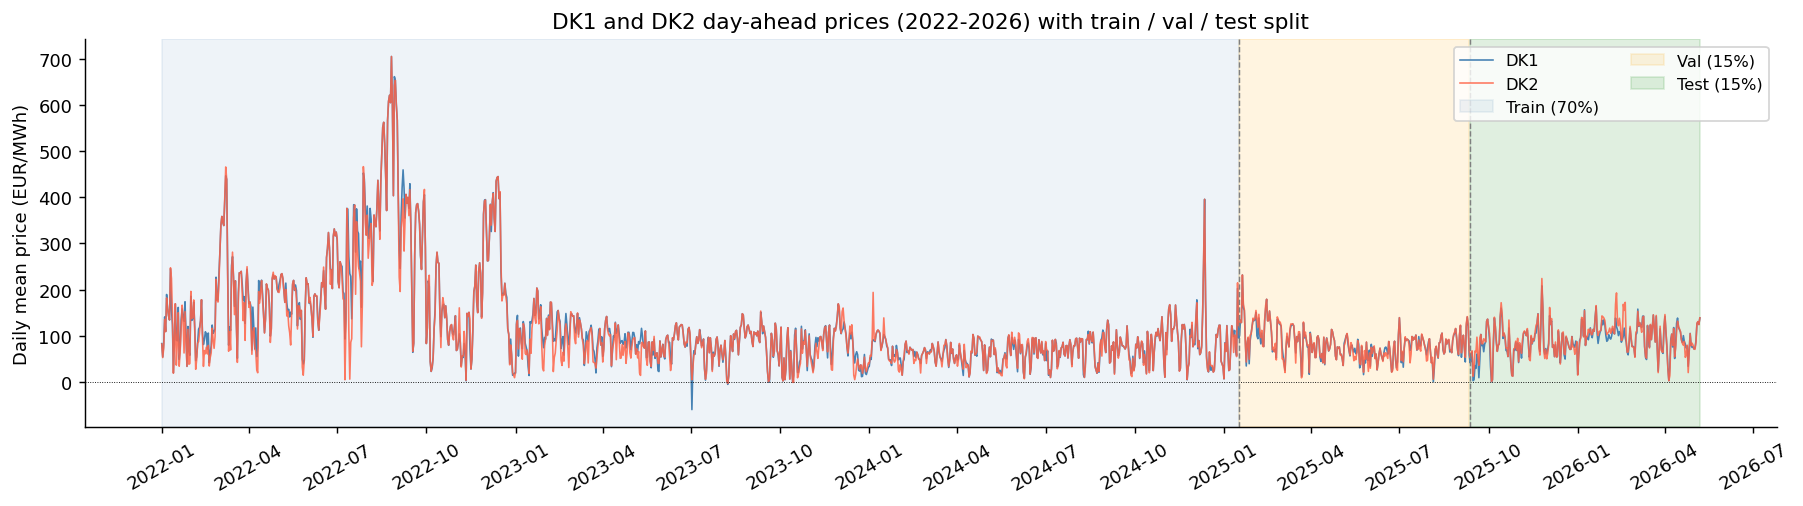

Train: 2022-01-01 -> 2025-01-16  (1109 days)
Val:   2025-01-17 -> 2025-09-11  (238 days)
Test:  2025-09-12 -> 2026-05-07  (238 days)


In [42]:
def unscale_zone(df_slice, zone, sc):
    cols = [c for c in df_slice.columns if c.startswith(zone + '_h')]
    z = df_slice[cols].values
    return (z * sc[zone]['std'] + sc[zone]['mean']).mean(axis=1)

df_2022 = df[df.index >= '2022-01-01'].copy()
n = len(df_2022)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
dates = df_2022.index

dk1 = pd.Series(unscale_zone(df_2022, 'DK1', scaler), index=dates)
dk2 = pd.Series(unscale_zone(df_2022, 'DK2', scaler), index=dates)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dk1.index, dk1.values, lw=0.9, color='steelblue', label='DK1')
ax.plot(dk2.index, dk2.values, lw=0.9, color='tomato', alpha=0.85, label='DK2')
ax.axvspan(dates[0],         dates[train_end-1], alpha=0.09, color='steelblue', label='Train (70%)')
ax.axvspan(dates[train_end], dates[val_end-1],   alpha=0.12, color='orange',    label='Val (15%)')
ax.axvspan(dates[val_end],   dates[-1],          alpha=0.12, color='green',     label='Test (15%)')
for cutoff in [train_end, val_end]:
    ax.axvline(dates[cutoff], color='grey', lw=0.8, ls='--')
ax.axhline(0, color='black', lw=0.5, ls=':')
ax.set_ylabel('Daily mean price (EUR/MWh)')
ax.set_title('DK1 and DK2 day-ahead prices (2022-2026) with train / val / test split')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'Train: {dates[0].date()} -> {dates[train_end-1].date()}  ({train_end} days)')
print(f'Val:   {dates[train_end].date()} -> {dates[val_end-1].date()}  ({val_end-train_end} days)')
print(f'Test:  {dates[val_end].date()} -> {dates[-1].date()}  ({n-val_end} days)')

In [43]:
regime_data = [
    ('2015 - Mar 2023',     'Pre-crisis stable + 2021-22 energy crisis',  1247),
    ('Apr 2023 - Oct 2024', 'Post-crisis + solar oversupply onset',        4929),
    ('Oct 2024 - May 2026', 'New normal (heavy solar)',                    3955),
]
regime_df = pd.DataFrame(regime_data, columns=['Period', 'Market character', 'Neg-price hours'])
regime_df.index = range(1, 4)
print('Regime shift: negative-price hours per era (all 7 zones combined)')
display(regime_df)
print()
print('Training on 2015-2026  ->  train-val ELBO gap ~0.34  (covariate shift from regime change)')
print('Training on 2022-2026  ->  train-val ELBO gap ~0.16  (same solar-era regime)')
print()
print('Decision: scope the VAE to the post-2022 market. Pre-2022 data is a different regime.')

Regime shift: negative-price hours per era (all 7 zones combined)


,Period,Market character,Neg-price hours
1,2015 - Mar 2023,Pre-crisis stable + 2021-22 energy crisis,1247
2,Apr 2023 - Oct 2024,Post-crisis + solar oversupply onset,4929
3,Oct 2024 - May 2026,New normal (heavy solar),3955



Training on 2015-2026  ->  train-val ELBO gap ~0.34  (covariate shift from regime change)
Training on 2022-2026  ->  train-val ELBO gap ~0.16  (same solar-era regime)

Decision: scope the VAE to the post-2022 market. Pre-2022 data is a different regime.


---
## 2. Architecture: Conditional Variational Autoencoder (CVAE)

The model separates **price features** from **market fundamentals**:

- **Encoder** $q_\phi(z \mid x, c)$: maps a day of prices $x \in \mathbb{R}^{168}$ and conditioning vector $c \in \mathbb{R}^{24}$ to a Gaussian posterior $\mathcal{N}(\mu_\phi, \sigma_\phi^2 I)$ over $z \in \mathbb{R}^{32}$.

- **Decoder** $p_\theta(x \mid z, c)$: reconstructs a synthetic price day from $(z, c)$.

**Training objective - ELBO with free-bits:**
$$\mathcal{L} = \mathbb{E}_q[\|x - \hat{x}\|_1] + \beta \sum_{k=1}^{32} \max(\lambda,\ \text{KL}(q_k \| \mathcal{N}(0,1)))$$
with $\beta$ annealed $0 \to 1$ over 100 warm-up epochs and free-bits floor $\lambda = 0.05$ to prevent posterior collapse.

**Conditioning vector** (24 dims): wind (DK1, DK2), solar (5 zones), load (7 zones), hydro actual generation (5 zones: NO1, NO2, SE3, SE4, FI), day-of-week and month cyclical features, public-holiday flag.

**MLP architecture:** hidden layers [512, 256, 128], SiLU activations, BatchNorm, 10% dropout.

**Sampling at inference:** Draw $z \sim \mathcal{N}(0, I)$, condition on real fundamentals $c$ from the test date, decode to a synthetic price day. This generates the counterfactual: *what prices consistent with the observed fundamentals on this day could the market have produced?*

In [44]:
import torch
from src.models.vae import CVAE

ckpt = torch.load('../checkpoints/sweep_g2_hydro/vae_best.pt', map_location='cpu', weights_only=False)
args  = ckpt['args']
price_cols = ckpt['price_cols']
cond_cols  = ckpt['cond_cols']

model = CVAE(
    price_dim=len(price_cols),
    cond_dim=len(cond_cols),
    hidden_dims=[512, 256, 128],
    latent_dim=args['latent_dim'],
    dropout=args['dropout'],
)
model.load_state_dict(ckpt['model_state'])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Model:         CVAE')
print(f'Parameters:    {n_params:,}')
print(f'Price dim:     {len(price_cols)}  (7 zones x 24 h, z-scored)')
print(f'Cond dim:      {len(cond_cols)}  ({args["cond_groups"]})')
print(f'Latent dim:    {args["latent_dim"]}')
print(f'Training:      {args["date_from"]} onward   |   val_frac={args["val_frac"]}   test_frac={args["test_frac"]}')
print(f'Beta / warmup: {args["beta"]} / {args["beta_warmup"]} epochs   |   free-bits lambda={args["free_bits"]}')

Model:         CVAE
Parameters:    532,968
Price dim:     168  (7 zones x 24 h, z-scored)
Cond dim:      24  (wind,solar,load,time,hydro)
Latent dim:    32
Training:      2022-01-01 onward   |   val_frac=0.15   test_frac=0.15
Beta / warmup: 1.0 / 100 epochs   |   free-bits lambda=0.05


---
## 3. Model Sweep

~20 configurations varying architecture (VAE / CVAE / LSTM-CVAE / flow-prior), beta schedule (fixed, cyclic, free-bits), and conditioning feature groups. All runs use 2022+ data, hidden dims [512, 256, 128], 1,000 epochs.

Key experiments:
- **Beta sweep** (β=1,2,4): higher β → posterior collapse (KL→0.005 at β=4).
- **Free-bits sweep** (λ=0.02/0.05/0.10): prevents collapse but doesn't improve test ELBO.
- **Feature group sweep**: the decisive experiment, only hydro actual generation consistently helps.
- **Flow prior (RealNVP)**: improves tail flexibility; distorts price levels.
- **LSTM-CVAE**: better cross-zone correlation, worse tail coverage.

In [45]:
sweep_rows = [
    ('run_2022',           'VAE',                          '-',   0.3746, 0.3986, '-',     'plain VAE'),
    ('sweep_g1_base',      'CVAE: wind+solar+load+time',   '19',  0.3764, 0.4638, 0.075,   ''),
    ('sweep_g2_hydro  *',  'CVAE: +hydro actual gen.',     '24',  0.3578, 0.4035, 0.065,   'BEST CVAE'),
    ('sweep_g3_reservoir', 'CVAE: +nuclear+reservoir',     '29',  0.4216, 0.4356, 0.051,   '+nuclear hurt'),
    ('sweep_g4_full',      'CVAE: +flows (all 10)',        '41',  0.4214, 0.4106, 0.054,   ''),
    ('cvae_beta4',         'CVAE beta=4, fb=0',            '24',  0.3599, 0.4851, 0.005,   'posterior collapse'),
    ('cvae_fb010',         'CVAE beta=1, fb=0.10',         '24',  0.4107, 0.4881, 0.117,   'over-regularised'),
    ('flow_vae',           'VAE + RealNVP prior',          '-',   0.2863, 0.3478, '-0.25', 'KL not comparable'),
    ('flow_cvae',          'CVAE g2 + RealNVP prior',      '24',  0.2492, 0.2605, '-0.17', 'KL not comparable'),
    ('lstm_cvae_w3',       'LSTM-CVAE W=3, g2_hydro',      '24',  '-',    '-',    '-',     'eval only'),
    ('baseline_207',       'VAE fair baseline (207 feat)', '-',   0.4107, 0.4379, 0.096,   'apples-to-apples'),
]
cols = ['Run', 'Config', 'Cond dims', 'Val ELBO', 'Test ELBO', 'KL', 'Notes']
sweep_df = pd.DataFrame(sweep_rows, columns=cols)
sweep_df.index = range(1, len(sweep_df) + 1)

def hl_best(row):
    color = "#6d9e79" if '*' in str(row['Run']) else ''
    return [f'background-color: {color}' for _ in row]

display(
    sweep_df.style
        .apply(hl_best, axis=1)
        .set_caption('Model sweep, all 2022+ runs  (ELBO = L1 recon + beta*KL, lower is better)')
)

,Run,Config,Cond dims,Val ELBO,Test ELBO,KL,Notes
1,run_2022,VAE,-,0.374600,0.398600,-,plain VAE
2,sweep_g1_base,CVAE: wind+solar+load+time,19,0.376400,0.463800,0.075000,
3,sweep_g2_hydro *,CVAE: +hydro actual gen.,24,0.357800,0.403500,0.065000,BEST CVAE
4,sweep_g3_reservoir,CVAE: +nuclear+reservoir,29,0.421600,0.435600,0.051000,+nuclear hurt
5,sweep_g4_full,CVAE: +flows (all 10),41,0.421400,0.410600,0.054000,
6,cvae_beta4,"CVAE beta=4, fb=0",24,0.359900,0.485100,0.005000,posterior collapse
7,cvae_fb010,"CVAE beta=1, fb=0.10",24,0.410700,0.488100,0.117000,over-regularised
8,flow_vae,VAE + RealNVP prior,-,0.286300,0.347800,-0.25,KL not comparable
9,flow_cvae,CVAE g2 + RealNVP prior,24,0.249200,0.260500,-0.17,KL not comparable
10,lstm_cvae_w3,"LSTM-CVAE W=3, g2_hydro",24,-,-,-,eval only


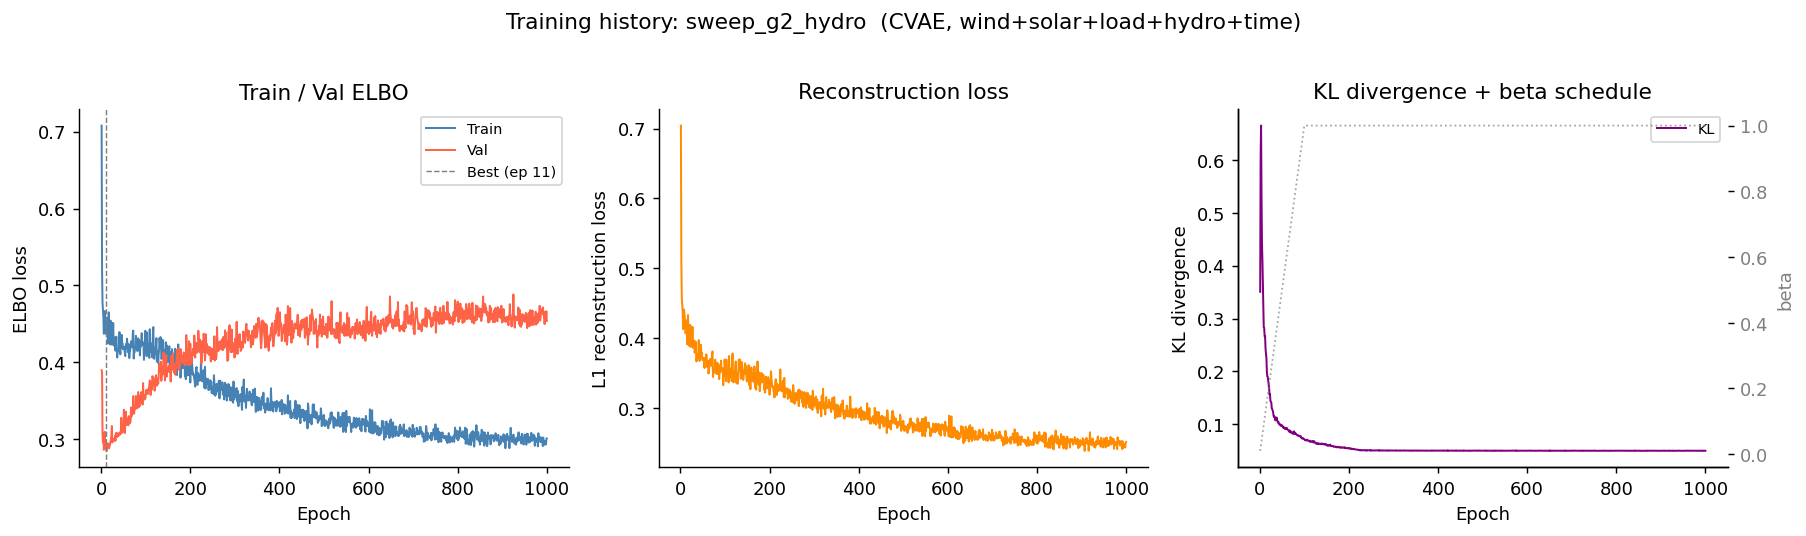

Best val ELBO:  0.2852  at epoch 11
Final train:    0.3014
KL at best:     0.2665


In [46]:
hist = pd.read_csv('../checkpoints/sweep_g2_hydro/training_history.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(hist['epoch'], hist['train'], lw=1.1, label='Train', color='steelblue')
ax.plot(hist['epoch'], hist['val'],   lw=1.1, label='Val',   color='tomato')
best_ep = int(hist['val'].idxmin())
ax.axvline(best_ep, color='grey', lw=0.8, ls='--', label=f'Best (ep {best_ep})')
ax.set_xlabel('Epoch'); ax.set_ylabel('ELBO loss')
ax.set_title('Train / Val ELBO'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(hist['epoch'], hist['recon'], lw=1.1, color='darkorange')
ax.set_xlabel('Epoch'); ax.set_ylabel('L1 reconstruction loss')
ax.set_title('Reconstruction loss')

ax = axes[2]
ax.plot(hist['epoch'], hist['kl'],   lw=1.1, color='purple',  label='KL')
ax2 = ax.twinx()
ax2.plot(hist['epoch'], hist['beta'], lw=1, color='grey', ls=':', alpha=0.7)
ax2.set_ylabel('beta', color='grey'); ax2.tick_params(axis='y', labelcolor='grey')
ax.set_xlabel('Epoch'); ax.set_ylabel('KL divergence')
ax.set_title('KL divergence + beta schedule'); ax.legend(fontsize=8)

plt.suptitle('Training history: sweep_g2_hydro  (CVAE, wind+solar+load+hydro+time)', y=1.02)
plt.tight_layout()
plt.show()

best_val = hist['val'].min()
best_kl  = hist.loc[hist['val'].idxmin(), 'kl']
print(f'Best val ELBO:  {best_val:.4f}  at epoch {best_ep}')
print(f'Final train:    {hist["train"].iloc[-1]:.4f}')
print(f'KL at best:     {best_kl:.4f}')

---
## 4. Distributional Evaluation

1,000 synthetic samples generated from `sweep_g2_hydro` and compared against the real test set (238 days). Conditioning $c$ is drawn from real test fundamentals. Each synthetic sample represents *what prices consistent with the observed fundamentals on that day could the market have produced*.

Plots pre-computed by `evaluate.py --checkpoint checkpoints/sweep_g2_hydro/vae_best.pt`.

Marginal price distribution: real vs synthetic (z-score) - four representative zones


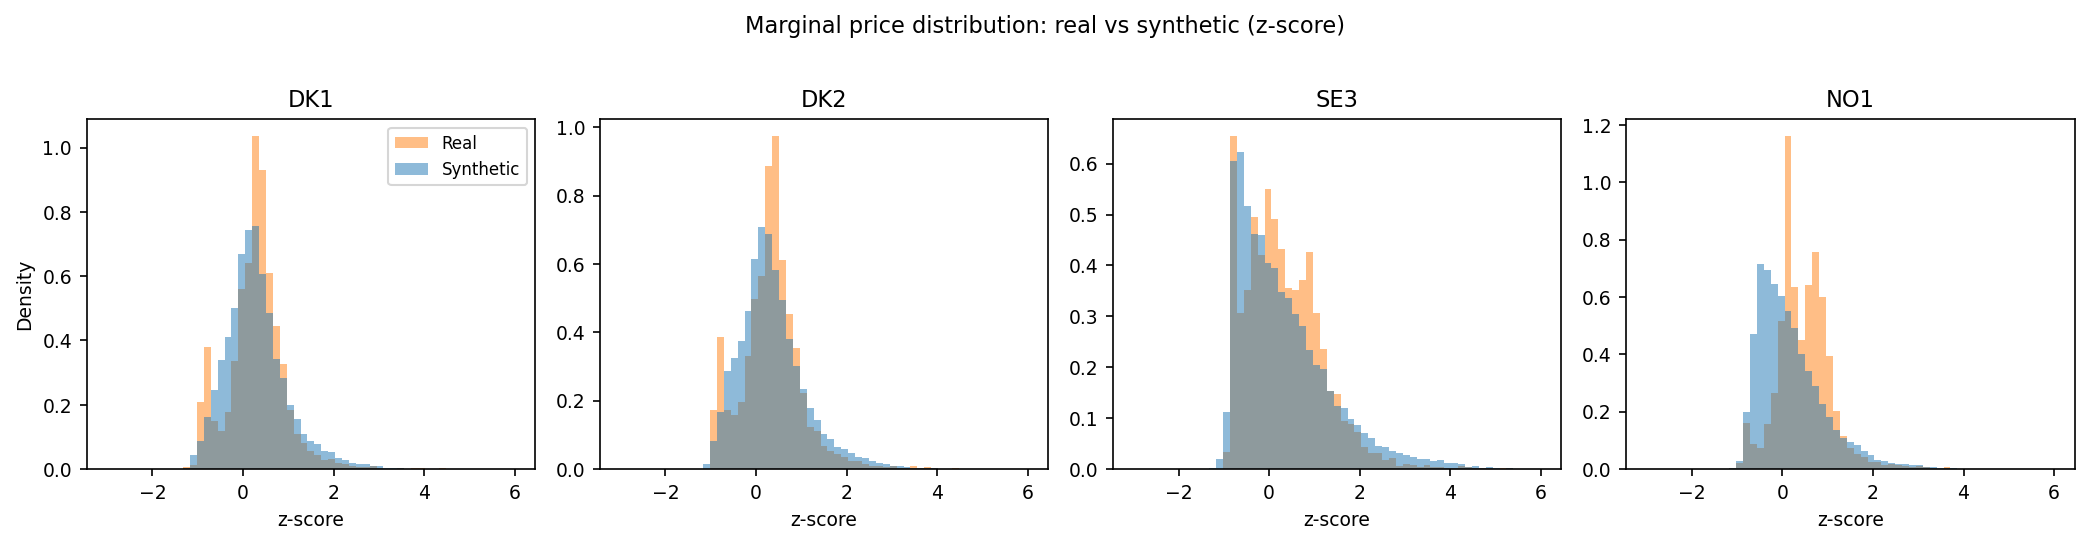

In [47]:
print('Marginal price distribution: real vs synthetic (z-score) - four representative zones')
display(Image('../checkpoints/sweep_g2_hydro/eval/dist_price.png'))

DK1-DK2 spread distribution (histogram + ECDF)


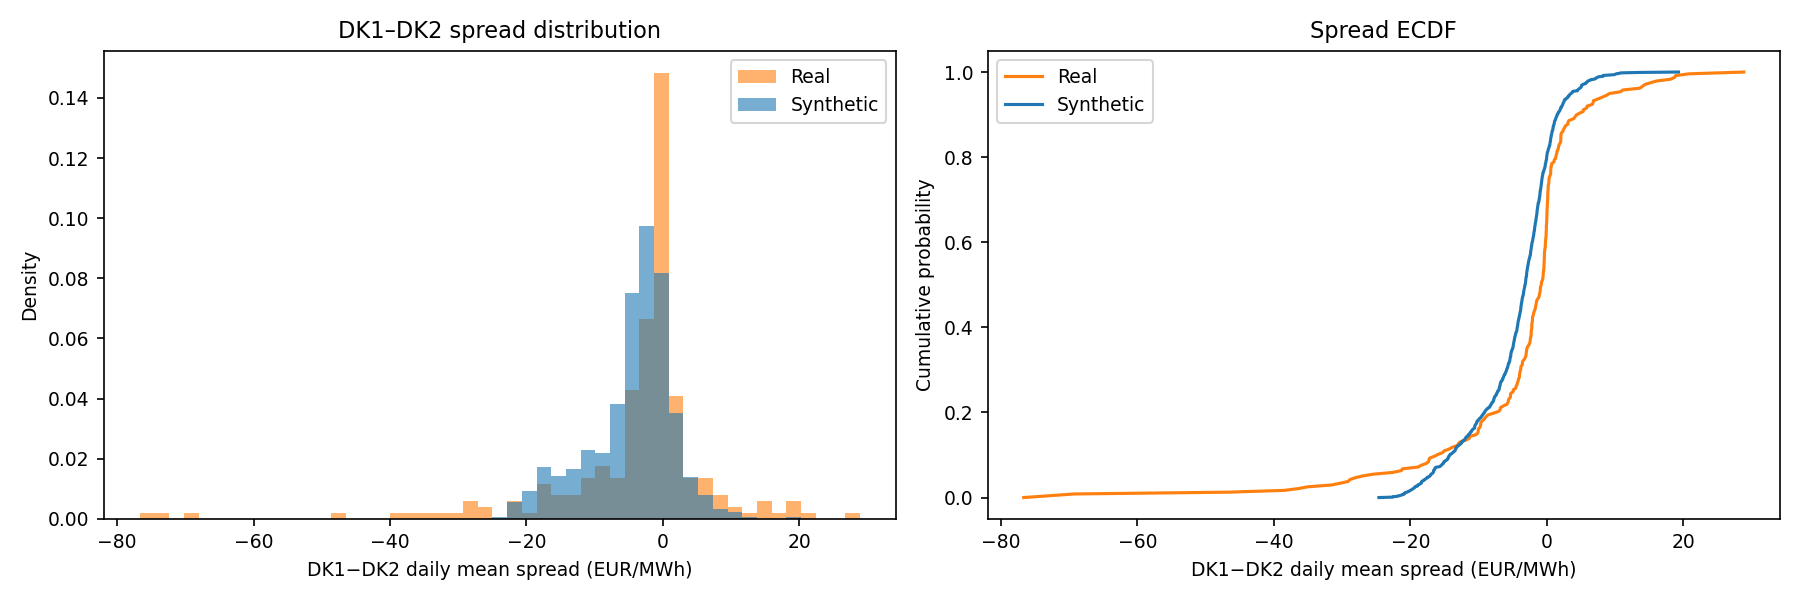

In [48]:
print('DK1-DK2 spread distribution (histogram + ECDF)')
display(Image('../checkpoints/sweep_g2_hydro/eval/dist_spread.png'))

Cross-zone Pearson correlation of daily mean prices (real left, synthetic right)


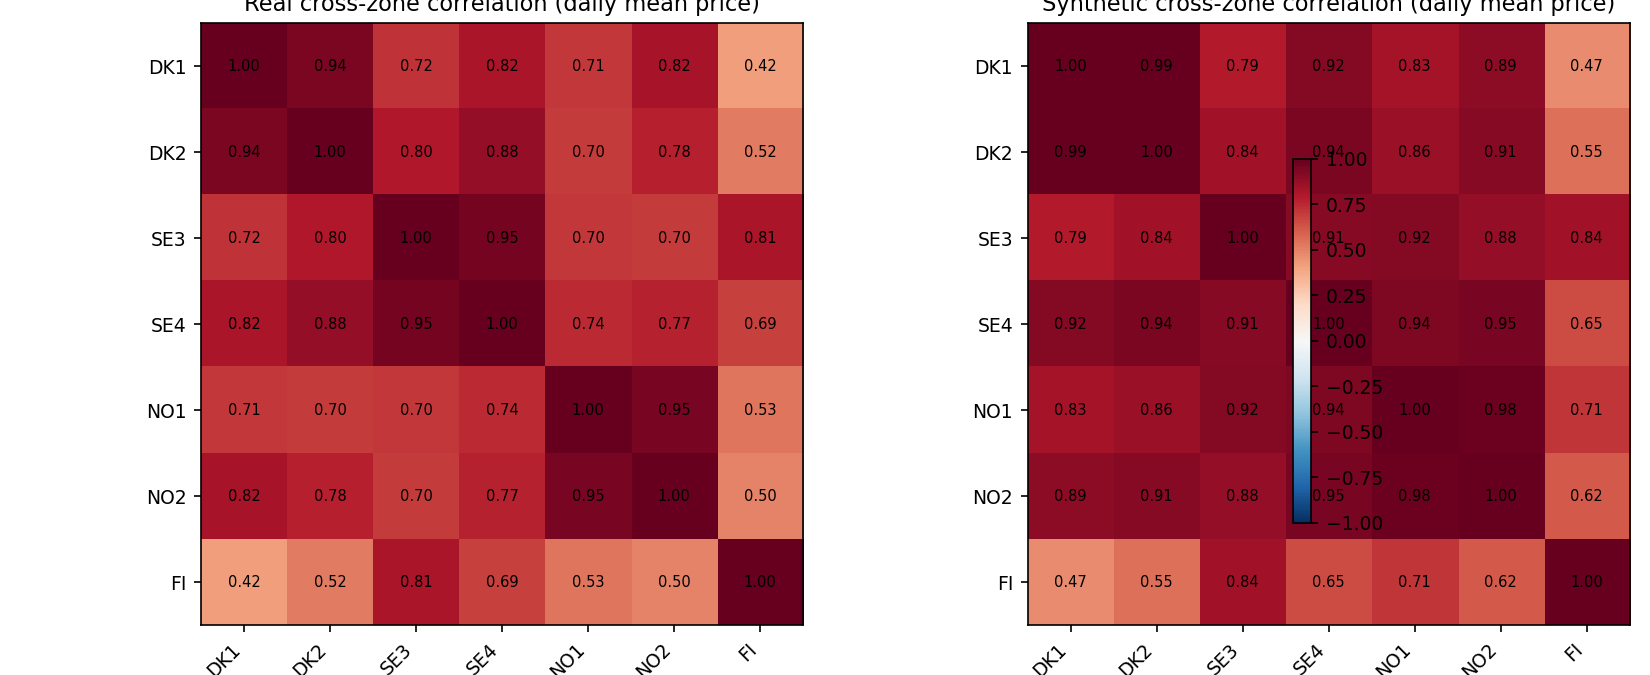

In [49]:
print('Cross-zone Pearson correlation of daily mean prices (real left, synthetic right)')
display(Image('../checkpoints/sweep_g2_hydro/eval/correlation.png'))

Tail coverage: fraction of zone-hours above each z-score threshold


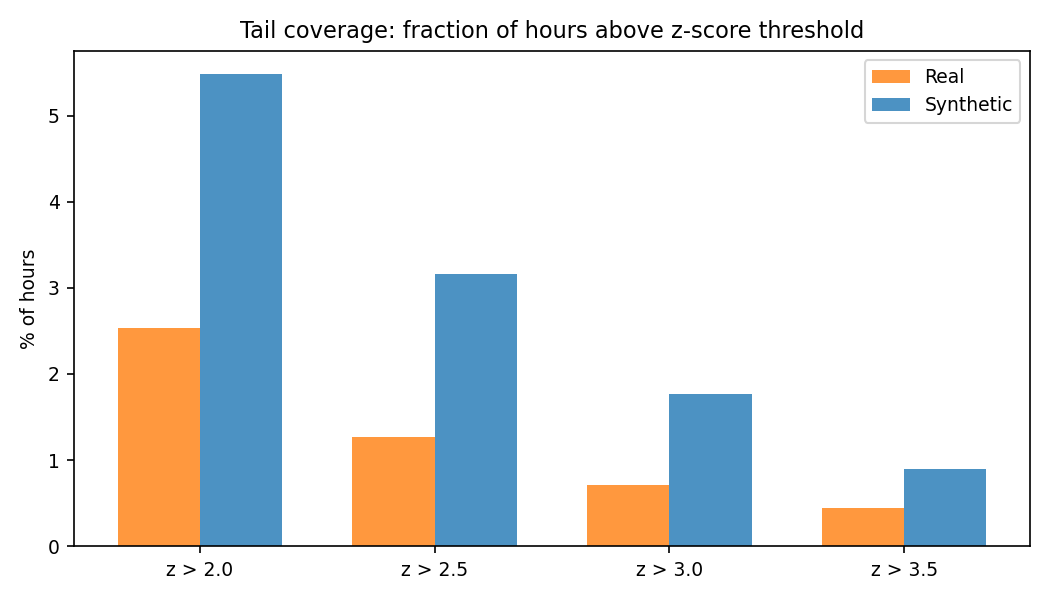

In [50]:
print('Tail coverage: fraction of zone-hours above each z-score threshold')
display(Image('../checkpoints/sweep_g2_hydro/eval/tail_coverage.png'))

In [55]:
eval_rows = [
    ('DK1 mean (EUR/MWh)',       89.77,  89.93,   120.73,  81.44,  81.82),
    ('DK1 std (EUR/MWh)',        48.72,  52.33,    94.29,  47.79,  42.14),
    ('KS statistic (DK1)',        None,   0.100,    0.181,  0.184,  0.156),
    ('Neg-price rate',            0.012,  0.021,    0.018,  0.029,  0.016),
    ('Tail ratio z>2',            1.00,   2.17,     4.64,   1.06,   0.95),
    ('Tail ratio z>3',            1.00,   2.50,     8.00,   0.52,   0.70),
    ('Corr MAE (cross-zone)',     None,   0.085,    0.133,  0.060,  0.077),
    ('Spread std (EUR/MWh)',     12.37,   6.18,     7.77,   6.87,   5.68),
    ('Spread VaR 5% (EUR/MWh)', -27.19, -17.21,   -2.45, -17.47, -17.36),
    ('Spread KS',                 None,   0.247,    0.397,  0.232,  0.488),
]
cols = ['Metric', 'Real', 'sweep_g2_hydro', 'baseline_207 (VAE)', 'lstm_cvae_w3', 'flow_cvae']
eval_df = pd.DataFrame(eval_rows, columns=cols).set_index('Metric')
print('Quantitative evaluation: 1,000 synthetic samples vs real test set (238 days)')
display(eval_df)
print()
print('sweep_g2_hydro: lowest KS (0.100), mean error 0.16 EUR/MWh.')
print('All models: spread std ~6-8 vs 12.4 EUR/MWh real - 50% compression, structural limitation.')

Quantitative evaluation: 1,000 synthetic samples vs real test set (238 days)


,Real,sweep_g2_hydro,baseline_207 (VAE),lstm_cvae_w3,flow_cvae
Metric,,,,,
DK1 mean (EUR/MWh),89.770,89.930,120.730,81.440,81.820
DK1 std (EUR/MWh),48.720,52.330,94.290,47.790,42.140
KS statistic (DK1),NaN,0.100,0.181,0.184,0.156
Neg-price rate,0.012,0.021,0.018,0.029,0.016
Tail ratio z>2,1.000,2.170,4.640,1.060,0.950
Tail ratio z>3,1.000,2.500,8.000,0.520,0.700
Corr MAE (cross-zone),NaN,0.085,0.133,0.060,0.077
Spread std (EUR/MWh),12.370,6.180,7.770,6.870,5.680
Spread VaR 5% (EUR/MWh),-27.190,-17.210,-2.450,-17.470,-17.360



sweep_g2_hydro: lowest KS (0.100), mean error 0.16 EUR/MWh.
All models: spread std ~6-8 vs 12.4 EUR/MWh real - 50% compression, structural limitation.


---
## 5. Backtest: DK1-DK2 Spread Strategy

Two strategies tested on the real test set (237 trading days). **Signal (position direction) is always the lagged *real* spread**. We are not testing signal quality, only whether synthetic prices produce the same PnL magnitude when used to settle trades.

- **Momentum**: always in market; long when yesterday's spread > 0, short otherwise. PnL = position × spread_{t+1}.
- **Reversion**: active 82/237 days; long when yesterday's spread < −5 EUR/MWh, short when > +5. PnL = position × Δspread_{t+1}.

200 synthetic paths generated per strategy via `backtest.py --checkpoint checkpoints/sweep_g2_hydro/vae_best.pt`.

Momentum strategy: cumulative PnL fan (200 synthetic paths) vs real


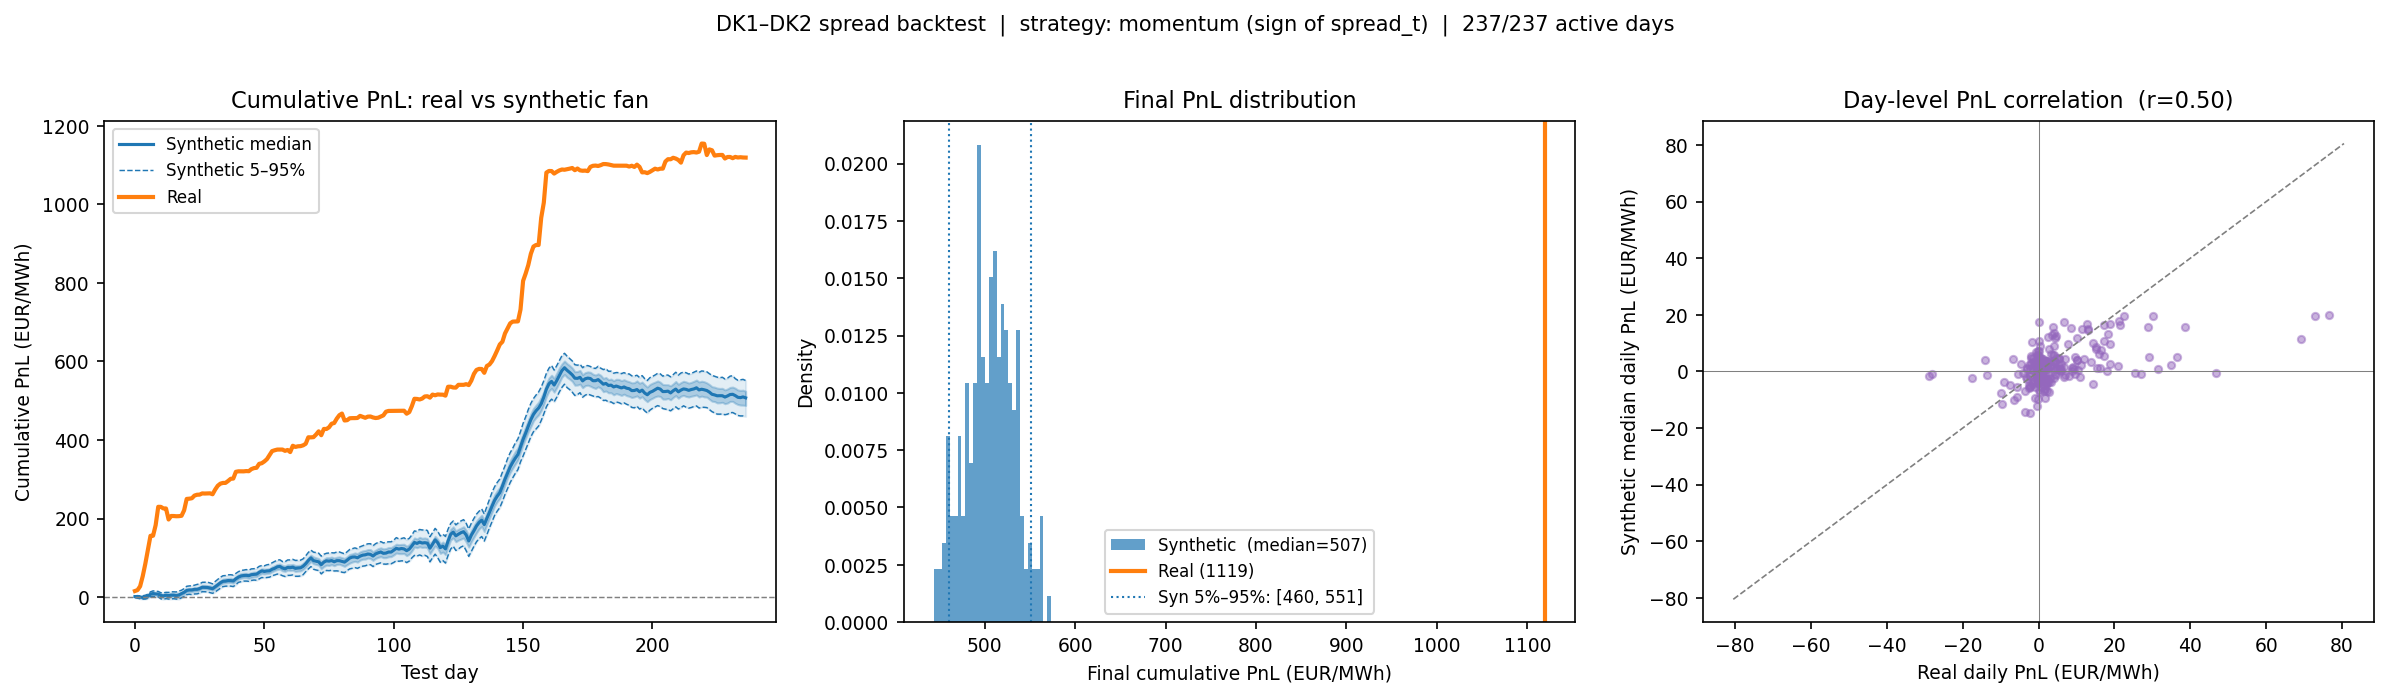

In [52]:
print('Momentum strategy: cumulative PnL fan (200 synthetic paths) vs real')
display(Image('../checkpoints/sweep_g2_hydro/backtest/pnl_momentum.png'))

Reversion strategy: cumulative PnL fan vs real


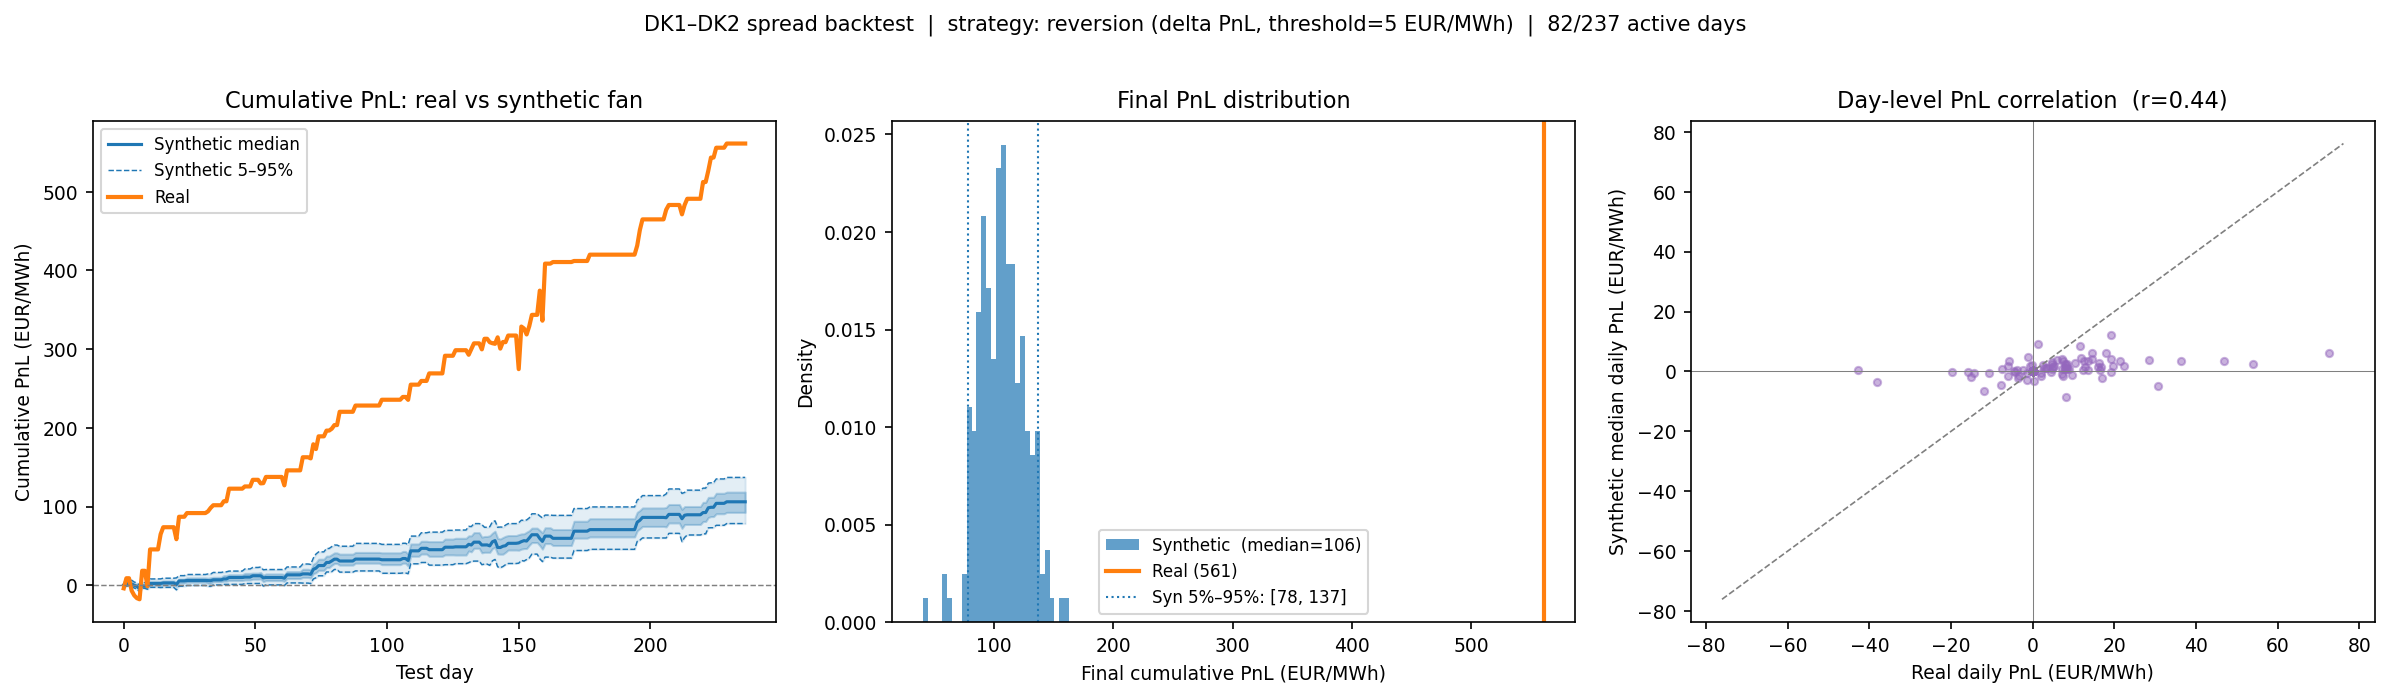

In [53]:
print('Reversion strategy: cumulative PnL fan vs real')
display(Image('../checkpoints/sweep_g2_hydro/backtest/pnl_reversion.png'))

In [54]:
bt_mom = pd.DataFrame({
    'Metric':       ['Total PnL (EUR/MWh)', 'Mean daily PnL', 'Std daily PnL', 'Ann. Sharpe', 'Max drawdown'],
    'Real':         [1119.4, 4.72, 12.08, 6.21, -38.1],
    'Syn p5':       [460,    None, None,  4.55,  None],
    'Syn p50':      [507,    2.13, 6.73,  5.05,  None],
    'Syn p95':      [552,    None, None,  5.47,  None],
}).set_index('Metric')
print('Momentum strategy:')
display(bt_mom)
print()

bt_rev = pd.DataFrame({
    'Metric':  ['Total PnL (EUR/MWh)', 'Std daily PnL', 'Ann. Sharpe'],
    'Real':    [561.3, 10.07, 3.74],
    'Syn p5':  [78,    None,  2.10],
    'Syn p50': [106,   2.54,  2.83],
    'Syn p95': [137,   None,  3.63],
}).set_index('Metric')
print('Reversion strategy (threshold +/-5 EUR/MWh, active 82/237 days):')
display(bt_rev)
print()
print('Real PnL lies entirely outside the synthetic 5-95% interval for both strategies.')
print('Root cause: synthetic spread std ~6 vs real ~12 EUR/MWh (50% compression).')
print('Direction is correct; magnitude is compressed ~2x.')

Momentum strategy:


,Real,Syn p5,Syn p50,Syn p95
Metric,,,,
Total PnL (EUR/MWh),1119.40,460.00,507.00,552.00
Mean daily PnL,4.72,NaN,2.13,NaN
Std daily PnL,12.08,NaN,6.73,NaN
Ann. Sharpe,6.21,4.55,5.05,5.47
Max drawdown,-38.10,NaN,NaN,NaN



Reversion strategy (threshold +/-5 EUR/MWh, active 82/237 days):


,Real,Syn p5,Syn p50,Syn p95
Metric,,,,
Total PnL (EUR/MWh),561.30,78.0,106.00,137.00
Std daily PnL,10.07,NaN,2.54,NaN
Ann. Sharpe,3.74,2.1,2.83,3.63



Real PnL lies entirely outside the synthetic 5-95% interval for both strategies.
Root cause: synthetic spread std ~6 vs real ~12 EUR/MWh (50% compression).
Direction is correct; magnitude is compressed ~2x.


---
## 6. Key Findings

### Conditioning is the single most important factor
Comparing `sweep_g2_hydro` (CVAE) to `baseline_207` (VAE) - same architecture, same data - conditioning halves KS distance (0.100 vs 0.181) and eliminates a +31 EUR/MWh mean bias. Without conditioning, the VAE generates high-price regimes without constraint.

### Hydro actual generation is the decisive feature
Of all feature groups tested, only hydro actual generation (B11+B12, real-time metered output) consistently improved the CVAE. Test ELBO drops from 0.464 (wind+solar+load+time) to 0.404 with hydro added. Hydro captures the dominant residual supply signal in Nordic markets: when hydro is abundant, prices are low and stable; when constrained, prices spike. Adding nuclear output and reservoir levels hurt, extra conditioning dims without marginal signal increase collapse pressure.

### All models underestimate spread volatility by ~50%
Synthetic DK1–DK2 spread std is 6–8 EUR/MWh vs 12.4 real. This is structural: the CVAE learns marginal zone price distributions but not the conditional joint spread distribution. No model tested overcame this without an explicit spread loss or spread-level conditioning.

### Directionally correct, not quantitatively calibrated
Both backtest strategies show the correct direction (profitable, same sign) and broadly correct Sharpe ratios (~80% of real). But absolute PnL is underestimated by ~55% because spread volatility is compressed. A researcher using only synthetic data would correctly rank strategies but would materially underestimate expected returns and drawdowns.

### Regime scoping to 2022+ is essential
Training on full 2015–2026 history produces a train–val gap of ~0.34 vs ~0.16 for 2022+. The pre-2022 data is a structurally different market, negligible negative-price hours, no solar oversupply, and introducing it causes covariate shift that no regularisation strategy closes.

---
## 7. Limitations

### Spread underestimation (structural)
All models underestimate DK1–DK2 spread volatility by ~50%. The VAE/CVAE learns marginal zone distributions; the conditional joint distribution of zone *differences* requires either an explicit spread loss term, conditioning on the current spread level, or an architecture that generates zone prices with an explicit coupling mechanism.

### Short training window
The 2022+ dataset contains ~1,100 training days, enough to learn dominant seasonal and solar patterns, but too short to reliably characterise the extreme tail (>3σ price spikes). The model has seen only a handful of true crisis events.

### Missing: Nord Pool bid/offer curves
The supply curve perturbation baseline, a merit-order-grounded benchmark providing an interpretable industry-standard comparison, could not be implemented. Historical bid/offer curves from Nord Pool are available only via commercial subscription. The ENTSO-E Transparency Platform does not publish historical Nordic bid curves with sufficient granularity. This is the single highest-value missing dataset.

### Missing: intraday and balancing prices
Nord Pool's continuous intraday market (XBID) and TSO balancing prices are not available through ENTSO-E. Balancing price divergence from day-ahead would improve tail modelling but requires commercial API access.

### Gaussian prior limits multimodal coverage
The $\mathcal{N}(0, I)$ prior cannot natively represent the multimodal regime distribution (normal days / crisis spikes / negative-price days). The flow prior (`flow_cvae`) addresses this but at the cost of price-level calibration. A mixture prior or regime-aware latent space is a more principled solution.

---
## 8. Future Directions with Nord Pool Data

### Supply curve perturbation baseline
With historical bid/offer curves (Nord Pool commercial subscription), a physically-grounded baseline becomes feasible:
1. Fit a parametric merit-order curve per hour per zone: `P = f(residual_load, net_flow)`.
2. Perturb curve parameters (slope, intercept) by drawing from fitted residuals, equivalent to simulating wind forecast errors or demand shocks.
3. Evaluate perturbed prices on the same spread strategies.

This baseline is interpretable to traders (perturbation magnitude maps to forecast error assumptions) and would establish whether the CVAE adds value over a physics-based approach. Without it, the true value-add of the generative model over simpler methods remains an open question.

### Improved spread modelling
With richer bid curve data, train a spread-conditional CVAE: condition not just on fundamental inputs but on the current DK1–DK2 spread level and binding interconnector capacity. This directly addresses the spread underestimation finding.

### Intraday scenario generation
Day-ahead prices set the anchor but strategy PnL also depends on intraday movements. With XBID intraday data, the CVAE could be extended to generate intraday price trajectories conditional on the day-ahead clearing.

### Longer post-solar history
Each additional year of 2022+ data improves the model's estimate of the tail. The training window grows by ~365 days/year; by 2028 it would double, meaningfully reducing uncertainty in the z>3 regime.

---
## 9. Generative Models for Energy Prices vs. Stock Markets

VAEs and generative models more broadly have seen success in equity markets. The assumptions that make them work in equities are substantially weaker than what energy markets require.

### Where equity assumptions hold better

**Stationarity.** Equity return distributions exhibit regime switches, but these unfold over years and the central tendency, positive drift with mean-reverting volatility, is stable across decades. A VAE trained on 10 years of S&P 500 daily returns faces a broadly consistent target. The Nordic electricity market underwent a *structural* regime change in approximately 18 months (2022–2023): a near-doubling of negative-price frequency driven by solar buildout. The 2015–2021 period is simply a different market.

**Continuity of the marginal distribution.** Stock returns are approximately continuous and broadly Gaussian in the body. Electricity prices are fundamentally different: bounded below by technical price caps (−500 EUR/MWh), subject to discrete zero-price episodes (when renewables flood the grid), and capped administratively (3,000–4,000 EUR/MWh). The distribution is structurally multimodal, normal day, oversupply day, scarcity day, and the modes are mechanistically distinct, not statistically extreme.

### Additional challenges in energy markets

**Merit-order discontinuities.** Prices jump discontinuously when the marginal generator technology changes. A generative model with a smooth latent space smooths over these steps, producing prices that look reasonable on average but miss the discrete jump structure at the tail. A supply curve perturbation approach is more faithful precisely because it preserves the step function structure by construction.

**Physical constraints.** Power grids have hard physical constraints, line capacity, ramp rates, reserve requirements, that determine when and by how much prices in adjacent zones can diverge. A purely statistical model has no knowledge of these constraints and will generate spread realisations inconsistent with binding capacity limits on specific days.

**Conditioning on fundamentals is non-optional.** In equity markets, a VAE trained purely on returns generates useful scenarios because the return distribution is relatively stationary across seasons. In electricity, conditioning is not an improvement,it is a prerequisite. An unconditioned model generates days with the wrong solar or hydro mix and therefore wrong prices. The `baseline_207` vs `sweep_g2_hydro` comparison (mean bias +31 EUR/MWh unconditioned) illustrates this starkly.

### Assessment

Generative models can add genuine value for electricity price scenario generation, but the bar is higher than in equities. The model must: (1) be regime-scoped to the current market structure, (2) condition on fundamentals that drive the current-regime price level, and (3) be evaluated against a physics-grounded baseline rather than statistical benchmarks alone. This project satisfies (1) and (2). The inability to implement (3) due to data access means the true value-add over simpler methods, such as historical bootstrap or supply curve perturbation, remains an open question for future work.